# J-lens readout on Qwen3-4B — pre-fitted lens vs logit lens

Does the Jacobian lens show the model's internal representations where the logit lens
does not, on the questions the model actually answers correctly? The lens is Anthropic's
own, fitted by this library's `fit_lens.py` on 1000 WikiText-103 sequences and downloaded
from `neuronpedia/jacobian-lens` — nothing is fitted here. Readouts are scored over
`data/evaluations`, whose `intermediates` are the words the model must "think about" on the
way to its answer but does not say.

A readout cannot show a computation the model never carried out, so every comparison and
conclusion below uses **only the questions Qwen3-4B answers correctly** (§2c). That leaves
the three sets with a `target` — `multihop`, `multilingual` and `order-ops`; `poetry`,
`association` and `typo` have no answer to check and are left out.

**Answer (this run, §6).** Mostly no — and the correctness filter sharpens that rather
than reversing it. Qwen3-4B answers **131 of 255** targeted questions correctly (multihop
34%, multilingual 65%, order-ops 53%; §2c). On those, taking the best rank over all
layers, the J-lens ranks the intermediates *worse* at k=1 (pass@1 0.119 vs 0.197; 0.155
vs 0.194 under fuzzy matching) and roughly ties the logit lens at k=5-10 (fuzzy 0.344 vs
0.335 and 0.484 vs 0.466, §4b/§4g). Its one clear lead is multihop at k=10 (0.710 vs
0.613). Both lenses only start hitting from about layer 26 of 36, the J-lens a layer or two
after the logit lens (§4e). In the mid-depth workspace band where the paper reads (layers
12-27), the logit lens wins at every k (0.019 vs 0.094 at k=1, 0.146 vs 0.274 at k=10,
§4c). So on this model and lens, the J-lens does not surface intermediates earlier or more
often than the logit lens. It does read internal content on individual questions —
` Italy` at rank 1 at layer 24 of *"the country shaped like a boot"*, where the logit lens
has it at rank 23 (§3a; slice pages for correct questions in §3d). The causal evidence is
stronger: in `concept_swap.ipynb`, J-lens directions flip 50% of correctly answered swaps
where logit-lens directions in the same early bands score 0.000.

## Method

**Lens.** `lens(h) = unembed(J_l h)` with `J_l = E[d h_final / d h_l]` averaged over source
positions, later positions and a pretraining-like corpus. `J_l` is a fitted
`d_model x d_model` matrix per layer; applying it is one matmul, so the readout costs the
same as the logit lens. The logit-lens baseline is the same pipeline with `J_l = I`.

**Shared activations.** `jlens.evaluation.evaluate_paired` takes one forward pass per
prompt and reads both lenses off the same pre-final-norm block outputs, so the comparison
cannot be confounded by sampling or by a different forward.

**Scoring** (`data/evaluations/README.md`): at each layer a word's score is its 1-based
rank in the lens's vocabulary distribution at the dataset's readout position, min over
spellings. pass@k averages, within an item, the fraction of words whose best-over-layers
rank is <= k, then averages over items. `control` words are another item's intermediates
and give the chance baseline.

**Question filter.** Before any lens is read, the model greedily generates a few tokens
for each prompt with a `target`. A question counts as answered correctly when that
continuation starts with the target (case-insensitive, ignoring leading whitespace and
quotes, and not followed by more ASCII letters or digits, so `200` does not count for
`20`). Generating instead of checking only the next token keeps the questions where Qwen's
tokenizer first emits a space or a word piece (`' '` before `20`, `pe` before `pequeño`).
Every table from §3b on uses these questions only.

**Why this is the claim.** The intermediates are not in the prompt and not in the output.
A readout that ranks them highly is reporting something the model computed internally.

## Setup

In [1]:
import os
import sys
from pathlib import Path

REPO_URL = "https://github.com/ai360-project-school-j-lens/jacobian-lens-gpt2.git"
REPO_DIR = os.path.abspath("jacobian-lens-gpt2")

# Opened from a clone (notebooks/<lens>/): use the repository root above the notebook.
local_repo = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "jlens" / "workspace.py").is_file()), None)
if local_repo is not None:
    REPO_DIR = str(local_repo)
elif os.path.isdir(REPO_DIR):
    !git -C {REPO_DIR} pull --ff-only
else:
    !git clone {REPO_URL} {REPO_DIR}
sys.path.append(REPO_DIR)

In [2]:
import gzip
import json
from functools import partial

import matplotlib.pyplot as plt
import pandas as pd
import torch
from IPython.display import display
from tqdm.auto import tqdm
from transformers import AutoModelForCausalLM, AutoTokenizer

import jlens
from jlens.evaluation import (
    DATASETS,
    evaluate_paired,
    fuzzy_spelling_ids,
    identity_lens,
    jacobian_lens,
    layer_hit_rate,
    layer_median_rank,
    load_eval,
    logit_lens,
    pass_at_k,
    plot_layer_curves,
    readout_position,
    single_token_ids,
    spelling_ids,
)
from jlens.hooks import ActivationRecorder
from jlens.metrics import evaluate_distributions, lens_vector_geometry
from jlens.reference_plots import (
    intermediate_rank_sweep,
    plot_distribution_summary,
    plot_intermediate_sweep,
    plot_lens_comparison,
)
from jlens.vis import _meaningful_token_mask
from jlens.workspace import final_norm_centers

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 240)

In [3]:
MODEL_ID = os.environ.get("JLENS_MODEL_ID", "Qwen/Qwen3-4B")
LENS_REPO = "neuronpedia/jacobian-lens"
LENS_FILE = {  # lenses fitted by this library's fit_lens.py on 1000 WikiText-103 x 128 tokens
    "Qwen/Qwen3-4B": "qwen3-4b/jlens/Salesforce-wikitext/Qwen3-4B_jacobian_lens.pt",
    "Qwen/Qwen3-1.7B": "qwen3-1.7b/jlens/Salesforce-wikitext/Qwen3-1.7B_jacobian_lens.pt",
}[MODEL_ID]
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE = torch.bfloat16 if DEVICE == "cuda" else torch.float32
SLUG = MODEL_ID.split("/")[-1].lower()
RUN_DIR = Path(os.environ.get("JLENS_RUN_DIR", Path(REPO_DIR) / "runs" / SLUG))
RUN_DIR.mkdir(parents=True, exist_ok=True)
torch.manual_seed(0)

In [4]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
hf_model = AutoModelForCausalLM.from_pretrained(MODEL_ID, dtype=DTYPE).to(DEVICE)
model = jlens.from_hf(hf_model, tokenizer)
lens = jlens.JacobianLens.from_pretrained(LENS_REPO, filename=LENS_FILE)

# Qwen3 is RMSNorm, so lens directions carry no centering term; probed, not assumed.
CENTERS = final_norm_centers(model)
assert lens.d_model == model.d_model, (lens.d_model, model.d_model)
print(f"{model}  layout={model.layout.path}  centers={CENTERS}")
print(f"lens: {lens.n_prompts} prompts, layers {lens.source_layers[0]}-{lens.source_layers[-1]}")
print(f"tokenizer: bos_token_id={tokenizer.bos_token_id}  dtype={DTYPE}  device={DEVICE}")

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

HFLensModel(Qwen3ForCausalLM, n_layers=36, d_model=2560)  layout=model  centers=False
lens: 479 prompts, layers 0-34
tokenizer: bos_token_id=None  dtype=torch.bfloat16  device=cuda


In [5]:
LAYER_STRIDE = max(1, model.n_layers // 12)
# Pickled, not CSV: both frames carry per-layer numpy arrays in a single cell.
OUT_WORDS = RUN_DIR / "readout_words.pkl"
OUT_ITEMS = RUN_DIR / "readout_items.pkl"
OUT_WORDS_FUZZY = RUN_DIR / "readout_words_fuzzy.pkl"
# The mid-depth band the paper reads the workspace over, as fractions of depth.
WORKSPACE_BAND = list(range(round(0.33 * model.n_layers), round(0.78 * model.n_layers)))
# Recorded with the results, per AGENTS.md's Experiment Configuration.
RUN_INFO = {
    "model_id": MODEL_ID,
    "dtype": str(DTYPE),
    "device": DEVICE,
    "n_layers": model.n_layers,
    "d_model": model.d_model,
    "lens_file": LENS_FILE,
    "lens_n_prompts": lens.n_prompts,
    "lens_corpus": "Salesforce/wikitext wikitext-103-raw-v1, 128 tokens/sequence",
    "final_norm_centers": CENTERS,
    "transformers": __import__("transformers").__version__,
    "torch": torch.__version__,
}
RUN_INFO

{'model_id': 'Qwen/Qwen3-4B',
 'dtype': 'torch.bfloat16',
 'device': 'cuda',
 'n_layers': 36,
 'd_model': 2560,
 'lens_file': 'qwen3-4b/jlens/Salesforce-wikitext/Qwen3-4B_jacobian_lens.pt',
 'lens_n_prompts': 479,
 'lens_corpus': 'Salesforce/wikitext wikitext-103-raw-v1, 128 tokens/sequence',
 'final_norm_centers': False,
 'transformers': '5.9.0',
 'torch': '2.12.0+cu130'}

## 1. Datasets

Six prompt sets from `data/evaluations`. Each item has a `prompt`, the `intermediates`
the model should pass through, and sometimes the `target` answer itself.

In [6]:
evals = {dataset: load_eval(REPO_DIR, dataset) for dataset in DATASETS}
print({dataset: len(items) for dataset, items in evals.items()})
print("total items:", sum(len(items) for items in evals.values()))
evals["multihop"][0]

{'multihop': 93, 'multilingual': 107, 'order-ops': 55, 'poetry': 98, 'association': 102, 'typo': 96}
total items: 551


{'name': 'carnival-ocean',
 'prompt': 'Fact: The ocean on the coast of the country where Carnival is most famously celebrated is the ',
 'target': 'Atlantic',
 'intermediates': ['Brazil']}

## 2. Sanity gates

Nothing below is worth reading unless these pass. The first checks that this adapter's
`unembed` really is the model's own head on this architecture; the second that the lens
machinery reduces exactly to the logit lens when `J_l = I`.

In [7]:
PROBE = "Fact: The currency used in the country shaped like a boot is"
ids = model.encode(PROBE)
with torch.no_grad():
    reference = hf_model(input_ids=ids).logits[0].float().cpu()
handwritten = logit_lens(model, PROBE)[-1].float().cpu()
rel_err = ((handwritten - reference).abs().max() / reference.abs().max()).item()
# bf16 carries ~3 decimal digits, so ~1e-3 is the noise floor here; a layout mistake
# (wrong norm, double unembed) would be O(1) and is what this gate is for.
GATE = 1e-4 if DTYPE == torch.float32 else 1e-2
print(f"unembed(final block) vs hf_model.logits: max rel err {rel_err:.2e}  (tol {GATE:g})")
assert rel_err < GATE, rel_err

unembed(final block) vs hf_model.logits: max rel err 0.00e+00  (tol 0.01)


In [8]:
identity = jacobian_lens(model, identity_lens(model), PROBE)
baseline = logit_lens(model, PROBE)
max_diff = (identity - baseline).abs().max().item()
print(f"identity lens vs logit lens: max abs diff {max_diff:.2e}")
assert max_diff < 1e-3, max_diff

identity lens vs logit lens: max abs diff 0.00e+00


### 2c. Which questions does the model answer correctly?

This is the filter for everything that follows, measured independently of any lens: the
model greedily continues each prompt for `MAX_NEW_TOKENS` tokens, and the question is
correct when the continuation starts with the `target` (see Method).

Three of the six sets carry a `target`. `poetry`, `association` and `typo` do not, so
correctness is undefined for them and they are excluded from the analysis below.

In [9]:
OUT_ANSWERS = RUN_DIR / "model_answers_generated.csv"
MAX_NEW_TOKENS = 8
ANSWER_BATCH = 32
LEADING = " \t\n\"'“”«»¿¡「『"


def answers_correctly(continuation, target):
    # Starts with the target, and an ASCII target is not followed by more letters or
    # digits ("200" is not "20"); CJK targets have no word boundary to check.
    text = continuation.lstrip(LEADING)
    if not text.lower().startswith(target.lower()):
        return False
    following = text[len(target):][:1]
    return not (following.isascii() and following.isalnum())


@torch.no_grad()
def greedy_continuations(prompts):
    # Grouped by length and left-padded, so every row generates from its last real token.
    order = sorted(range(len(prompts)), key=lambda i: len(model.encode_ids(prompts[i])))
    texts = [None] * len(prompts)
    for start in tqdm(range(0, len(order), ANSWER_BATCH), desc="answers"):
        chunk = order[start:start + ANSWER_BATCH]
        batch = tokenizer([prompts[i] for i in chunk], return_tensors="pt", padding=True,
                          padding_side="left").to(DEVICE)
        generated = hf_model.generate(**batch, max_new_tokens=MAX_NEW_TOKENS, do_sample=False,
                                      pad_token_id=tokenizer.pad_token_id)
        decoded = tokenizer.batch_decode(generated[:, batch.input_ids.shape[1]:],
                                         skip_special_tokens=True)
        for i, text in zip(chunk, decoded, strict=True):
            texts[i] = text
    return texts


if OUT_ANSWERS.exists():
    answers = pd.read_csv(OUT_ANSWERS, keep_default_na=False)
    print("loaded cached answers")
else:
    answers = pd.DataFrame([
        {"dataset": dataset, "item": item["name"], "prompt": item["prompt"].rstrip(),
         "target": item["target"]}
        for dataset, items_of in evals.items() for item in items_of if "target" in item
    ])
    answers["continuation"] = greedy_continuations(answers.prompt.tolist())
    answers["model_correct"] = [answers_correctly(text, target) for text, target
                                in zip(answers.continuation, answers.target, strict=True)]
    answers.to_csv(OUT_ANSWERS, index=False)

accuracy = answers.groupby("dataset").agg(
    accuracy=("model_correct", "mean"), correct=("model_correct", "sum"),
    items=("model_correct", "size")).round(3)
display(accuracy)
print("datasets without a target (excluded):", sorted(set(evals) - set(answers.dataset)))
WITH_TARGET = sorted(set(answers.dataset))
CORRECT_ITEMS = set(map(tuple, answers.loc[answers.model_correct, ["dataset", "item"]].values))
CORRECT_EVALS = {dataset: [item for item in evals[dataset]
                           if (dataset, item["name"]) in CORRECT_ITEMS]
                 for dataset in WITH_TARGET}
print(f"{len(CORRECT_ITEMS)} of {len(answers)} targeted questions answered correctly")


def correct_only(frame):
    # Rows of correctly answered questions; every metric below is taken on these.
    keys = zip(frame.dataset, frame.item, strict=True)
    return frame[[key in CORRECT_ITEMS for key in keys]]

loaded cached answers


,accuracy,correct,items
dataset,,,
multihop,0.344,32,93
multilingual,0.654,70,107
order-ops,0.527,29,55


datasets without a target (excluded): ['association', 'poetry', 'typo']
131 of 255 targeted questions answered correctly


In [10]:
# What the model says when it is right and when it is wrong.
shown = []
for _, group in answers.groupby("dataset"):
    for correct in (True, False):
        subset = group[group.model_correct.eq(correct)]
        if not subset.empty:
            shown.append(subset.iloc[0])
display(pd.DataFrame(shown)[["dataset", "item", "target", "continuation", "model_correct"]]
        .set_index(["dataset", "model_correct"]))

item    target                                 continuation
dataset      model_correct                                                                             
multihop     True                 carnival-ocean  Atlantic            Atlantic Ocean.\nCarnival is most
             False                    mars-color       red   green.\nIs the following statement true?\n
multilingual True           spanish-opposite-big   pequeño                       pequeño", pero ¿qué op
             False          german-opposite-loud     leise                         : \n\nA) still  \nB)
order-ops    True                parens-add-mult        20                 20. Is this equation correct
             False                add-mult-right        14                                    12 + 3 *

## 3a. What the two lenses read at the readout position

The prompt needs *Italy* (shape -> country) to get to *euro* (country -> currency).
*Italy* is the internal step: it is in neither the prompt nor the answer.

In [11]:
jl = jacobian_lens(model, lens, PROBE)
ll = logit_lens(model, PROBE)
position = -1
rows = []
for layer in range(0, model.n_layers, LAYER_STRIDE):
    for name, logits in (("J-lens", jl), ("logit lens", ll)):
        top = logits[layer, position].topk(6).indices.tolist()
        rows.append({"layer": layer, "lens": name,
                     "top-6": " ".join(repr(tokenizer.decode([i])) for i in top)})
display(pd.DataFrame(rows).pivot(index="layer", columns="lens", values="top-6"))
print("model output:", [tokenizer.decode([i]) for i in jl[-1, position].topk(6).indices.tolist()])

lens,J-lens,logit lens
layer,,
0,' –' ' …\n\n' ' ….' '….\n\n' '”.\n\n' '’.\n\n','/is' 'lington' '館' 'rael' '紋' '该县'
3,'…”' '”\n' '.”\n' '…”\n\n' '”，' '”.\n\n','ocratic' '/is' 'ucht' 'omers' 'rael' '-roll'
6,'`.\n\n' '”。\n\n' '`\n\n' '`.\n' '。\n\n' '”.\n\n','[number' 'もっと' '間違い' 'oven' '끔' 'ance'
9,' \\`' '`.\n\n' '`.\n' '`;\n\n' '帼' ' &#',' 물론' '끔' ' Федер' '全过程' '-but' '[number'
12,' \\`' '`.\n' '`.\n\n' ' […' ' Britain' '。\n','-shaped' ' shaped' '瘾' '[number' '_lib' 'ólica'
15,'吗' '。\\' '？\n' '哪个' ' \\`' '？\n\n','蓉' '-shaped' '地区的' '꼴' ' victories' '全国人民'
18,'？\n' '？\n\n' ')?\n' '？”' ')?\n\n' '?”\n\n',' countries' '全国人民' ' located' ' namely' 'eder...
21,')?\n\n' ')?\n' '?</' '.*/\n' '?”\n\n' ';*/\n',' victories' ' where' '其中之一' '其中一个' ' one' ' f...
24,' Italy' '意大利' '欧元' '英镑' 'Italy' ' Italian',' called' ' currently' ' named' ' typically' '...


model output: [' the', ' called', ' ', ' Euro', '欧元', '?\n']


### 3b. The same readout on correctly answered questions

§3a is one prompt. This repeats it for one correctly answered question from each set with a
`target`, at that set's own readout position (the last prompt token). Change `PICK` to walk
through the other correct questions of a set (`CORRECT_EVALS`, §2c).

In [12]:
# Index into each set's correctly answered questions; sets with none are skipped.
PICK = {dataset: 0 for dataset, items_of in CORRECT_EVALS.items() if items_of}


def readout_table(dataset, index, top_n=6, layer_stride=None):
    #-layer top tokens of both lenses at this dataset's readout position.
    item = CORRECT_EVALS[dataset][index]
    prompt = item["prompt"].rstrip()
    ids = model.encode(prompt)[0].tolist()
    position = readout_position(tokenizer, ids, dataset)
    stride = layer_stride or LAYER_STRIDE
    jl_logits, ll_logits = jacobian_lens(model, lens, prompt), logit_lens(model, prompt)
    rows = []
    for layer in sorted({*range(0, model.n_layers, stride), model.n_layers - 1}):
        entry = {"layer": layer}
        for name, logits in (("J-lens", jl_logits), ("logit lens", ll_logits)):
            top = logits[layer, position].topk(top_n).indices.tolist()
            entry[name] = " ".join(repr(tokenizer.decode([i])) for i in top)
        rows.append(entry)
    return item, position, pd.DataFrame(rows).set_index("layer")


for dataset, index in PICK.items():
    item, position, table = readout_table(dataset, index)
    print("=" * 100)
    print(f"{dataset} / {item['name']}   readout position {position}")
    print(f"prompt: {item['prompt'].rstrip()!r}")
    print(f"intermediates: {item['intermediates']}   target: {item.get('target', '-')}")
    display(table)

multihop / carnival-ocean   readout position 17
prompt: 'Fact: The ocean on the coast of the country where Carnival is most famously celebrated is the'
intermediates: ['Brazil']   target: Atlantic


,J-lens,logit lens
layer,,
0,' ：' 's' '：' '：\n' ' \\\\' '：\n\n',"'館' 'öne' '<>(""' '<Texture' 'vang' 'SPORT'"
3,'”\n' '…\n' '.”\n' '…”' '，' '**\n','館' '<Texture' 'SPORT' 'enville' 'atron' 'ALLE'
6,'？\n\n' '。\n\n' '，' '？' '：\n\n' '：','款' 'cus' '\xadt' 'tas' '结' 'lí'
9,'？\n\n' '；' '！\n\n' '。\n\n' '：' '，','款' '吸引' '池' '湾' '仅次于' 'だ'
12,'海域' '海洋' '海岸' '海上' '海水' ' ocean','bay' ' area' ' basin' ' ocean' ' Ocean' ' Sec...
15,'海域' '海岸' '海洋' '海水' '岛屿' '海',' vast' '際' ' bordered' ' …\n\n' ' Ob' '_between'
18,'海域' '海岸' '海洋' ' coastal' '沿海' ' coastline',"' vast' ' ""' ' land' ' end' ' almost' ' largest'"
21,'海域' '海岸' '海洋' '地理' '沿海' '岛屿',"' land' '��' ' central' ' ""' ' most' 'land'"
24,' ocean' ' Ocean' '海岸' '海域' ' coastal' '海洋',' ocean' ' most' ' sea' ' same' ' surrounding'...


multilingual / spanish-opposite-big   readout position 9
prompt: 'Lo opuesto de "grande" es "'
intermediates: ['Spanish', 'opposite', 'big', 'small']   target: pequeño


,J-lens,logit lens
layer,,
0,"' ""\n\n' ' ""\n' ' ""\r\n' ' """"""\n\n' ' ""' ' the...","'...""' ' ""' '..."",' 'nels' '...""\n' ' "")""'"
3,"' ""\n' ' ""\r\n' ' ""\n\n' '""\n' '""\n\n' ' "".\n'","'+\'""' '!=""' '[]""' 'sth' ""'-"" 'lip'"
6,"' ""\n' ' ""\r\n' ' ""\n\n' ' """"""\n\n' ' "".\n' '""...",'形' '并' '“' 'ento' 'sth' '(es'
9,"' ""\n' ' ""\n\n' ' "".\n' '""\n\n' '.""\n\n' '"".\n\n'","'dale' '...""' '通讯员' 'ző' '_SPLIT' 'ischer'"
12,"'.""\n' '"".\n' '.""\n\n' '"".\n\n' '""\n' '...""\n'",'___' 'a' 'í' '____' '是什么' ' ____'
15,"'.""\n' '.""' '?""\n' '"".\n' '.""\n\n' '!""'",'____' ' ____' 'í' '是什么' '�' '\n\n'
18,"'?""\n' '""?' '?""' '.""\n' '.""' '...""'",'____' '___' ' ____' '是什么' ' ______' ' __'
21,"'""?' '.""' '?""' '?""\n\n' '?""\n' '.""\n\n'",'____' '___' ' ____' '什么呢' ' ______' ' __'
24,"'""?' '"",' '"".' '?"",' '"".\n' '?""\n'",'____' ' ____' '___' '________' '__' ' ______'


order-ops / parens-add-mult   readout position 9
prompt: '(2 + 3) * 4 ='
intermediates: ['5', 'multiplication']   target: 20


,J-lens,logit lens
layer,,
0,' \\\\\n' ' \\' ' ``' ' ：' ' =\n\n' ' $','什么呢' 'ぇ' '该县' ' =\r\n' 'enville' '__;\n'
3,'$\n' '：\n' ' =\n' '*\n' ' *\n' '。\n','enville' '什么呢' 'UsageId' 'иг' '理解和' 'WXYZ'
6,' =\n' ' =' '：\n' ' 的' ' *=' ' =\n\n','ysz' '什么呢' '-il' '在现场' '_()\n' '_)\r\n'
9,'：\n' ' =\n' '？\n' ' =' ' :\n' ' （','系统的' '他们在' 'ysz' '?=' 'quence' '梯'
12,'？\n' '：\n' '.\n' '!\n' '，' '?\n','的结果' 'ysz' ' Div' '顺势' '式的' '此刻'
15,"',' '.' '""?' '，' ':\n' '？'",'的结果' '解答' ' overall' '的整体' '结果' '整体'
18,"'？\n' '____' '？' '?\n' '?""\n' ' ______'",'的结果' ' result' '结果' ' ______' '___' '_'
21,"'？\n' '?\n' ':\n' '____' '：\n' '?"";\n'",'的结果' ' result' '的整体' ' ______' ' outcome' ' p...
24,'？\n' '？\n\n' '?\n\n' '？' '?\n' '?',' ?\n\n' ' ?\n' '?\n\n' ' ?' '?\n' '?'


### 3c. Rank of the intermediate (` Italy`) and the target (` euro`) by layer

The J-lens should put *Italy* near the top somewhere in the middle of the network, and
the logit lens should not.

,J-lens ' Italy',logit ' Italy',J-lens ' euro',logit ' euro'
layer,,,,
0,3405,78024,13488,90034
3,30728,129696,111970,117123
6,65852,40696,28141,111705
9,104202,47548,23332,46194
12,148,1369,3887,107552
15,20164,4776,34595,20362
18,2251,7432,43178,14116
21,3820,969,40383,9358
24,1,23,74,249


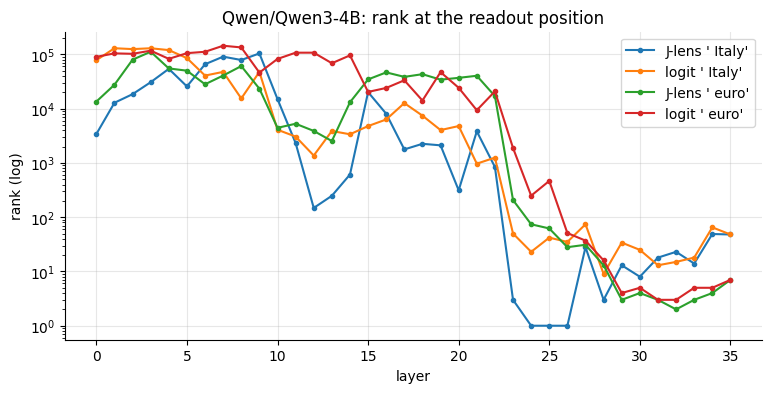

In [13]:
# 1-based rank of a word's first token at every layer.
def rank_of(logits, word, position=-1):
    ids = tokenizer.encode(word, add_special_tokens=False)
    scores = logits[:, position]
    return ((scores > scores[:, ids[0]].unsqueeze(-1)).sum(-1) + 1).cpu().numpy()

ranks = pd.DataFrame({
    "J-lens ' Italy'": rank_of(jl, " Italy"),
    "logit ' Italy'": rank_of(ll, " Italy"),
    "J-lens ' euro'": rank_of(jl, " euro"),
    "logit ' euro'": rank_of(ll, " euro"),
}, index=range(model.n_layers))
ranks.index.name = "layer"
display(ranks.iloc[::LAYER_STRIDE])
fig, ax = plt.subplots(figsize=(9, 4))
for column in ranks:
    ax.plot(ranks.index, ranks[column], marker=".", label=column)
ax.set_yscale("log")
ax.set_xlabel("layer")
ax.set_ylabel("rank (log)")
ax.set_title(f"{MODEL_ID}: rank at the readout position")
ax.legend()
ax.grid(alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)
plt.show()

### 3d. Position x layer slice — the paper's figure

The interactive view from the paper: a cell per (token position, layer) showing the lens's
top-1, with its full-vocabulary rank as a superscript. The bottom row (`L = n_layers - 1`)
is the model's own output. Click a cell to pin a token and track its rank everywhere.

`mask_display=True` restricts the *displayed* tokens to word-like ones and `alt_token`
glosses Qwen's CJK tokens into English — both exist in this repo because Qwen's raw top-K
is dominated by punctuation and CJK pieces (visible in §3a). Ranks stay full-vocabulary.

Pinned words use the same fuzzy matching as §4g (every vocabulary spelling of the word), so
a Qwen numeral is never pinned as a bare space. The first page is the §3a probe; the ones
after it are one correctly answered question from each set with a `target` (`PICK`, §3b).

In [14]:
from jlens.vis import build_page, compute_slice, notebook_iframe

GLOSS = {int(k): v for k, v in
         json.loads(gzip.open(Path(REPO_DIR) / "assets/qwen_gloss.json.gz").read()).items()}
print(f"{len(GLOSS)} glossed token ids")


def slice_page(prompt, title, description, track=(), height=640, top_n=8, max_tracked=80,
               expand=False):
    # max_tracked bounds the embedded rank tensor; without it the page dominates the
    # notebook's size (len(tracked) * seq_len * n_layers * 4 bytes before compression).
    pinned = set().union(*(fuzzy_spelling_ids(tokenizer, w, expand) for w in track))
    data = compute_slice(model, lens, prompt, top_n=top_n, max_tracked=max_tracked,
                         pinned_token_ids=pinned, layer_stride=LAYER_STRIDE,
                         mask_display=True)
    page, raw, payload = build_page(data, prompt, title=title, description=description,
                                   mode="embed", alt_token=GLOSS)
    print(f"{len(page) / 1e6:.2f} MB page, {len(data.tracked_token_ids)} tracked tokens")
    return notebook_iframe(page, height=height)


slice_page(PROBE, title="J-lens on Qwen3-4B",
           description="Two-hop: shape -> Italy -> euro. Pinned: Italy, euro.",
           track=("Italy", "euro"))

91695 glossed token ids


0.41 MB page, 83 tracked tokens


In [15]:
# One correctly answered question per set with a target (§2c), intermediates and target pinned.
for dataset, index in PICK.items():
    item = CORRECT_EVALS[dataset][index]
    print(f"{dataset} / {item['name']}: intermediates {item['intermediates']}, "
          f"target {item['target']!r}")
    display(slice_page(item["prompt"].rstrip(),
                       title=f"J-lens: {dataset} / {item['name']} (answered correctly)",
                       description=f"intermediates {item['intermediates']}, "
                                   f"target {item['target']}",
                       track=(*item["intermediates"], item["target"]),
                       expand=dataset == "order-ops"))

multihop / carnival-ocean: intermediates ['Brazil'], target 'Atlantic'


0.44 MB page, 84 tracked tokens


multilingual / spanish-opposite-big: intermediates ['Spanish', 'opposite', 'big', 'small'], target 'pequeño'
0.40 MB page, 91 tracked tokens


order-ops / parens-add-mult: intermediates ['5', 'multiplication'], target '20'


0.41 MB page, 113 tracked tokens


## 4. Correctly answered questions

One forward pass per prompt, both lenses off the same activations, cached so re-executing
the notebook does not repeat it. The cache covers all 551 items; the rows are then
restricted to the questions the model answers correctly (§2c) before any metric is taken.

In [16]:
if OUT_WORDS.exists() and OUT_ITEMS.exists():
    words, items = pd.read_pickle(OUT_WORDS), pd.read_pickle(OUT_ITEMS)
    print("loaded cached readouts")
else:
    words, items = evaluate_paired(model, lens, evals)
    words.to_pickle(OUT_WORDS)
    items.to_pickle(OUT_ITEMS)
words_all, items_all = words, items
words, items = correct_only(words_all), correct_only(items_all)
print(len(words), "word rows,", len(items), "item rows on correctly answered questions")
words.head(3)

loaded cached readouts
1718 word rows, 262 item rows on correctly answered questions


,dataset,item,kind,word,role,single_token,in_prompt,ranks,best_rank,best_layer,lens
0,multihop,carnival-ocean,intermediate,Brazil,0,True,False,"[4484, 7616, 3277, 11244, 25067, 94914, 51568,...",116,35,logit lens
1,multihop,carnival-ocean,control,China,0,True,False,"[42588, 38949, 54042, 89132, 84150, 85377, 299...",836,20,logit lens
2,multihop,carnival-ocean,target,Atlantic,0,True,False,"[48632, 43079, 42704, 62527, 60694, 20813, 190...",1,28,logit lens


### 4a. pass@k over all words, by kind

In [17]:
scores = pass_at_k(words)
display(scores.pivot_table(index=["dataset", "kind"], columns=["lens", "k"], values="score").round(3))

lens                      J-lens                      logit lens                     
k                            1      5      10     100        1      5      10     100
dataset      kind                                                                    
multihop     control       0.031  0.031  0.031  0.167      0.031  0.031  0.031  0.167
             intermediate  0.125  0.500  0.688  0.812      0.312  0.469  0.594  0.844
             target        0.750  0.781  0.781  0.906      0.750  0.844  0.844  1.000
multilingual control       0.000  0.010  0.014  0.058      0.008  0.033  0.038  0.065
             intermediate  0.214  0.343  0.396  0.564      0.243  0.400  0.493  0.661
             target        0.586  0.757  0.857  0.986      0.471  0.786  0.814  0.971
order-ops    control       0.018  0.036  0.179  0.625      0.018  0.036  0.125  0.661
             intermediate  0.017  0.103  0.276  0.810      0.034  0.138  0.310  0.810
             target        0.069  0.069  0.103  0.517      0.069  0.069  0.103  0.586

### 4b. Intermediates only — the headline comparison

`control` is the chance baseline (another item's intermediates), so the number that
matters is intermediate minus control, J-lens vs logit lens.

In [18]:
summary = (pass_at_k(words)
           .pivot_table(index=["kind", "k"], columns="lens", values="score")
           .round(3))
summary["J - logit"] = (summary["J-lens"] - summary["logit lens"]).round(3)
display(summary)

lens              J-lens  logit lens  J - logit
kind         k                                 
control      1     0.016       0.019     -0.003
             5     0.025       0.033     -0.008
             10    0.075       0.065      0.010
             100   0.283       0.298     -0.015
intermediate 1     0.119       0.197     -0.078
             5     0.315       0.336     -0.021
             10    0.453       0.466     -0.013
             100   0.729       0.772     -0.043
target       1     0.468       0.430      0.038
             5     0.536       0.566     -0.030
             10    0.581       0.587     -0.006
             100   0.803       0.853     -0.050

### 4c. Restricted to the workspace band

pass@k above takes the best rank over *all* layers, which flatters the logit lens: at the
last layers it is the model's own output distribution. The paper reads the workspace over a
mid-depth band instead (`data/evaluations/README.md`), so this repeats the comparison with
only those layers available to both lenses.

In [19]:
print("band layers:", WORKSPACE_BAND[0], "-", WORKSPACE_BAND[-1])
band = (pass_at_k(words, layers=WORKSPACE_BAND)
        .pivot_table(index=["kind", "k"], columns="lens", values="score")
        .round(3))
band["J - logit"] = (band["J-lens"] - band["logit lens"]).round(3)
display(band)

band layers: 12 - 27


lens              J-lens  logit lens  J - logit
kind         k                                 
control      1     0.000       0.009     -0.009
             5     0.000       0.017     -0.017
             10    0.000       0.023     -0.023
             100   0.068       0.186     -0.118
intermediate 1     0.019       0.094     -0.075
             5     0.103       0.219     -0.116
             10    0.146       0.274     -0.128
             100   0.344       0.656     -0.312
target       1     0.031       0.064     -0.033
             5     0.113       0.161     -0.048
             10    0.169       0.229     -0.060
             100   0.292       0.448     -0.156

In [20]:
display(pass_at_k(words[words.kind.eq("intermediate")], layers=WORKSPACE_BAND)
        .pivot_table(index="dataset", columns=["lens", "k"], values="score").round(3))

lens         J-lens                      logit lens                     
k               1      5      10     100        1      5      10     100
dataset                                                                 
multihop      0.000  0.188  0.281  0.500      0.156  0.312  0.312  0.688
multilingual  0.057  0.121  0.157  0.361      0.107  0.275  0.389  0.607
order-ops     0.000  0.000  0.000  0.172      0.017  0.069  0.121  0.672

### 4d. Is the gap an artifact of Qwen's vocabulary?

The J-lens readout is visibly full of CJK tokens and punctuation (§3), and a full-vocabulary
rank punishes that even where the right concept is present. `jlens.vis` already has the mask
used for display (`mask_display=True`); here it is applied to the *ranks*, over the
correctly answered questions of the two datasets where both lenses do best. If the J-lens only looked worse because of non-word
tokens, masking would close the gap.

In [21]:
wordlike = _meaningful_token_mask(tokenizer, model._lm_head.weight.shape[0], model.input_device)
print(f"word-like tokens: {int(wordlike.sum())} of {wordlike.numel()}")

rows = []
for dataset in ("multihop", "multilingual"):
    for item in CORRECT_EVALS[dataset]:
        prompt = item["prompt"].rstrip()
        ids = model.encode(prompt)
        position = readout_position(tokenizer, ids[0].tolist(), dataset)
        with torch.no_grad(), ActivationRecorder(model.layers, at=WORKSPACE_BAND) as recorder:
            model.forward(ids)
            acts = {l: recorder.activations[l].detach() for l in WORKSPACE_BAND}
        for word in item["intermediates"]:
            ids_of_word = sorted(spelling_ids(tokenizer, word))
            if not ids_of_word:
                continue
            index = torch.tensor(ids_of_word, device=model.input_device)
            best = {"J-lens": (10**9, 10**9), "logit lens": (10**9, 10**9)}
            for layer in WORKSPACE_BAND:
                h = acts[layer][0, position].float()
                for name, residual in (("J-lens", lens.transport(h, layer)), ("logit lens", h)):
                    logits = model.unembed(residual).float()
                    full = int((logits > logits[index].max()).sum()) + 1
                    masked_logits = logits.masked_fill(~wordlike, -float("inf"))
                    masked = int((masked_logits > masked_logits[index].max()).sum()) + 1
                    best[name] = (min(best[name][0], full), min(best[name][1], masked))
            for name, (full, masked) in best.items():
                rows.append({"dataset": dataset, "lens": name, "full": full, "masked": masked})

masked_ranks = pd.DataFrame(rows)
table = pd.concat(
    {f"@{k}": masked_ranks.assign(full_hit=masked_ranks.full <= k, masked_hit=masked_ranks.masked <= k)
     .groupby(["dataset", "lens"])[["full_hit", "masked_hit"]].mean()
     for k in (1, 5, 10)}, axis=1).round(3)
display(table)

word-like tokens: 121220 of 151936


@1                  @5                 @10           
                        full_hit masked_hit full_hit masked_hit full_hit masked_hit
dataset      lens                                                                  
multihop     J-lens        0.000      0.000    0.188      0.219    0.281      0.312
             logit lens    0.156      0.156    0.312      0.312    0.312      0.312
multilingual J-lens        0.057      0.125    0.121      0.246    0.157      0.357
             logit lens    0.107      0.171    0.275      0.343    0.389      0.429

### 4e. Where in depth does each lens find the intermediates?

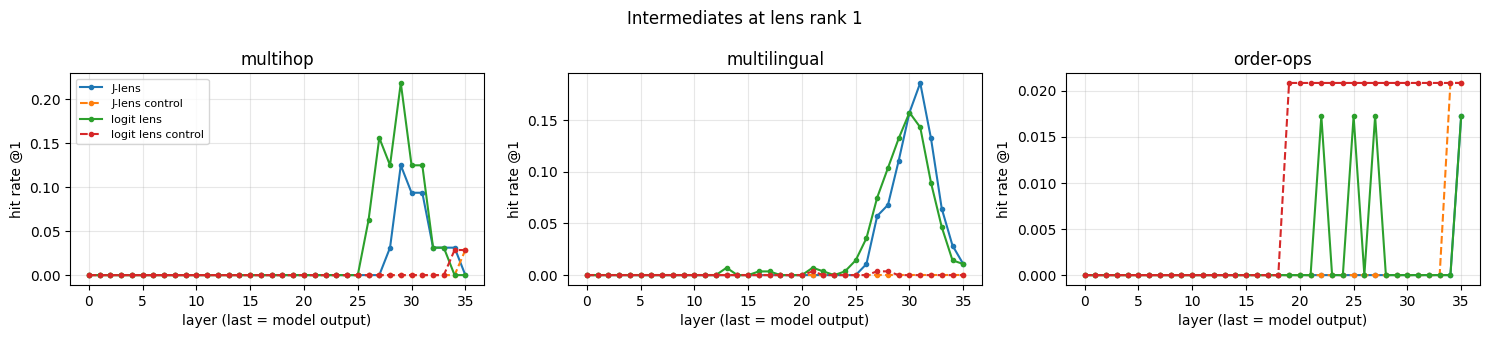

In [22]:
hits, medians = {}, {}
for name in ("J-lens", "logit lens"):
    for kind in ("intermediate", "control"):
        subset = words[words.lens.eq(name) & words.kind.eq(kind)]
        label = name if kind == "intermediate" else f"{name} control"
        hits[label] = layer_hit_rate(subset, k=1)
        medians[label] = layer_median_rank(subset)
plot_layer_curves(hits, "Intermediates at lens rank 1", "hit rate @1")
plt.show()

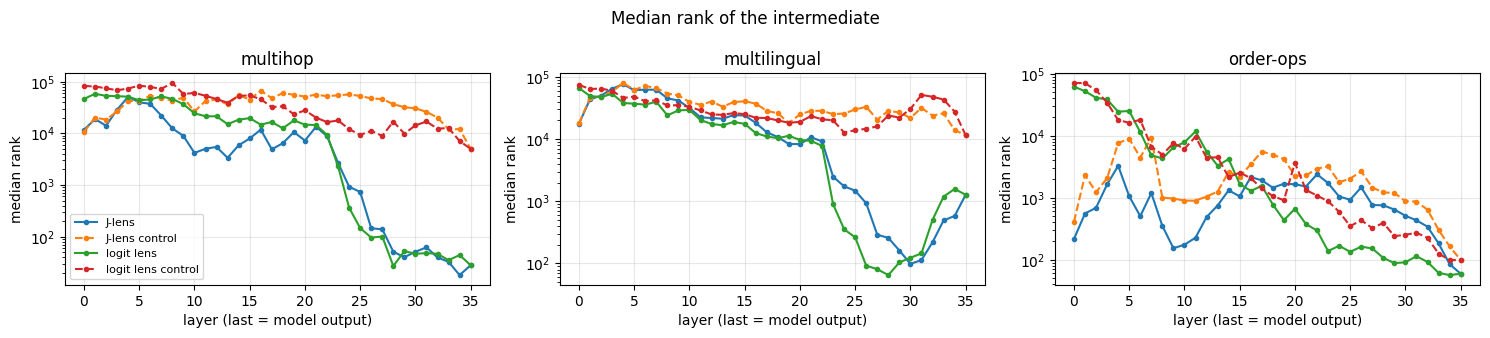

In [23]:
plot_layer_curves(medians, "Median rank of the intermediate", "median rank", logy=True)
plt.show()

### 4f. Figure 52 adaptation: intermediate rank sweep over k

lens,J-lens,logit lens
dataset,,
multihop,0.589,0.586
multilingual,0.403,0.483
order-ops,0.334,0.332


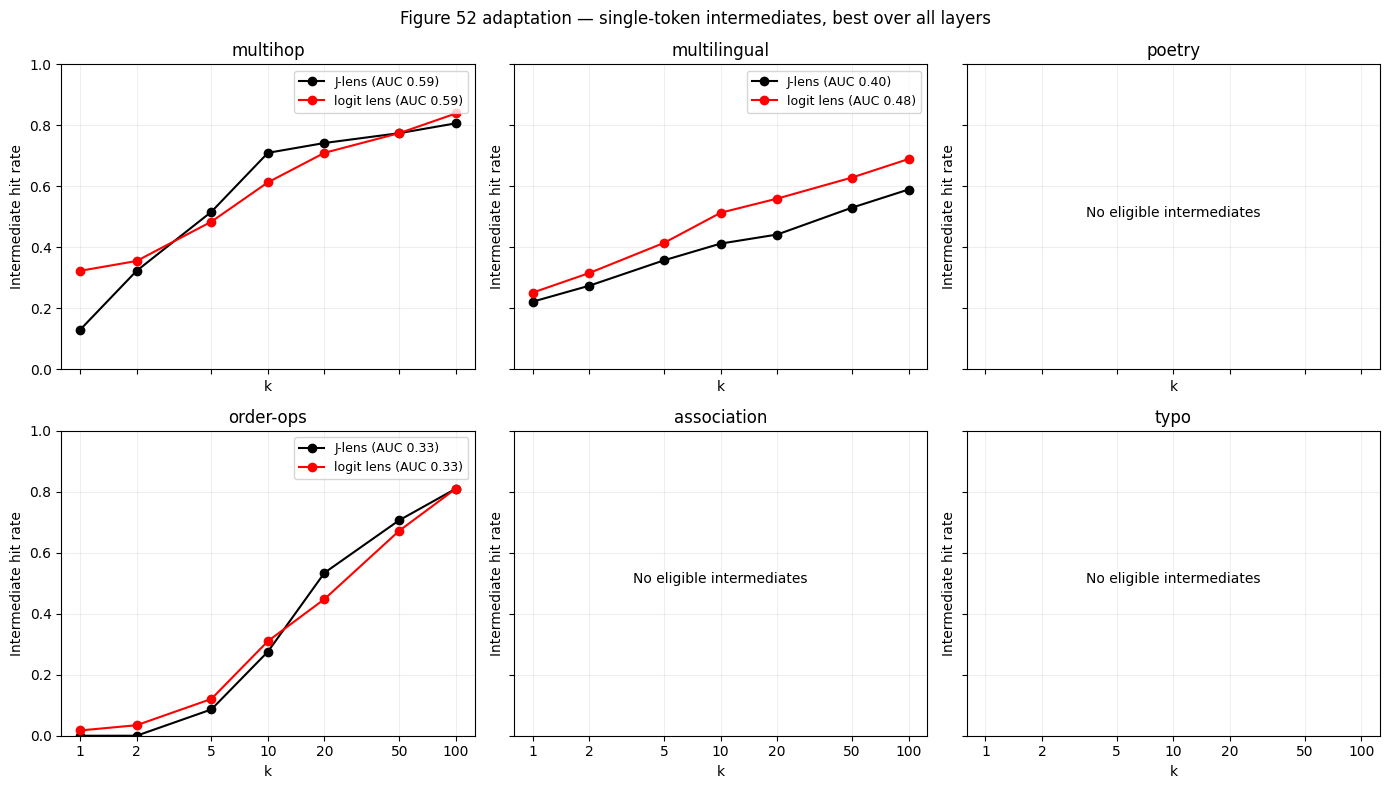

In [24]:
sweep = intermediate_rank_sweep(words)
# AUC is trapezoidal in log(k), normalised by log(k_max/k_min): one number per lens/task.
display(sweep.scores.pivot_table(index="dataset", columns="lens", values="auc").round(3))
plot_intermediate_sweep(sweep)
plt.show()

### 4g. Fuzzy spelling match

Scoring a word means deciding which token ids count as the model saying it, and on Qwen
that is not straightforward. `jlens.evaluation.fuzzy_spelling_ids` has three arms:

1. **Exact** — every vocabulary token whose decoded text equals the word ignoring
   surrounding whitespace and case, so `' Italy'` and `'Italy'` are one answer. This is a
   superset of the default `single_token_ids`, which can only construct variants it
   guesses at; the full-vocabulary scan finds the rest.
2. **Prefix** — for a word with no single-token form, the first token of its own
   tokenization, accepted only when that decodes to a non-whitespace prefix of at least
   two characters (or one, if non-ASCII, since a CJK token carries much more of the word).
   This is what makes `tellurium`, `automne` and `火曜日` scorable at all.
3. **Unscorable** — otherwise nothing, and the word is *excluded*. The default
   `spelling_ids` instead falls back to the first token of `" word"`, which for a Qwen
   numeral is a bare space: a very common next token that scores as a hit whenever the
   continuation happens to be whitespace.

The prefix arm raises absolute hit rates for both lenses, so the strict and fuzzy runs are
reported side by side rather than one replacing the other.

In [25]:
coverage = []
for dataset, items_of in CORRECT_EVALS.items():
    for item in items_of:
        pairs = [("intermediate", w) for w in item["intermediates"]]
        if "target" in item:
            pairs.append(("target", item["target"]))
        for kind, word in pairs:
            expand = dataset == "order-ops"
            strict = sorted(spelling_ids(tokenizer, word, expand))
            exact = fuzzy_spelling_ids(tokenizer, word, expand, prefix=False)
            full = fuzzy_spelling_ids(tokenizer, word, expand)
            coverage.append({
                "dataset": dataset, "kind": kind, "word": word,
                "exact adds vs single_token_ids": len(exact - single_token_ids(tokenizer, word, expand)) > 0,
                "rescued by prefix": not exact and bool(full),
                "unscorable": not full,
                "strict was whitespace-only": bool(strict) and all(
                    not tokenizer.decode([i]).strip() for i in strict),
            })
coverage = pd.DataFrame(coverage)
display(coverage.groupby("dataset")[[
    "exact adds vs single_token_ids", "rescued by prefix", "unscorable",
    "strict was whitespace-only"]].sum())
print("spot checks:")
for word in ("Italy", "tellurium", "automne", "火曜日", "26"):
    got = sorted(fuzzy_spelling_ids(tokenizer, word))
    print(f"  {word!r:12} -> {[repr(tokenizer.decode([i])) for i in got] or 'UNSCORABLE'}")

,exact adds vs single_token_ids,rescued by prefix,unscorable,strict was whitespace-only
dataset,,,,
multihop,20,0,4,4
multilingual,144,39,4,0
order-ops,53,3,0,3


spot checks:
  'Italy'      -> ["' Italy'", "'Italy'"]
  'tellurium'  -> ["' tell'"]
  'automne'    -> ["' autom'"]
  '火曜日'        -> ["'火'"]
  '26'         -> UNSCORABLE


In [26]:
if OUT_WORDS_FUZZY.exists():
    words_fuzzy = pd.read_pickle(OUT_WORDS_FUZZY)
    print("loaded cached fuzzy readouts")
else:
    words_fuzzy, _ = evaluate_paired(
        model, lens, evals, "paired lenses (fuzzy)",
        spelling_lookup=partial(fuzzy_spelling_ids, tokenizer),
    )
    words_fuzzy.to_pickle(OUT_WORDS_FUZZY)
# Unscorable words carry ranks=None and must be dropped before pass_at_k stacks them.
scored_fuzzy_all = words_fuzzy[words_fuzzy.ranks.notna()]
scored_fuzzy = correct_only(scored_fuzzy_all)
print(f"{len(scored_fuzzy)} of {len(correct_only(words_fuzzy))} word rows on correctly "
      "answered questions are scorable under fuzzy matching")

loaded cached fuzzy readouts
1698 of 1718 word rows on correctly answered questions are scorable under fuzzy matching


In [27]:
def intermediate_summary(frame, label):
    table = (pass_at_k(frame[frame.kind.eq("intermediate")])
             .pivot_table(index="k", columns="lens", values="score").round(3))
    table["J - logit"] = (table["J-lens"] - table["logit lens"]).round(3)
    return table.assign(matching=label).set_index("matching", append=True)


display(pd.concat([
    intermediate_summary(words, "strict (spelling_ids)"),
    intermediate_summary(scored_fuzzy, "fuzzy (exact + prefix)"),
]).reorder_levels(["matching", "k"]).sort_index())

lens                        J-lens  logit lens  J - logit
matching               k                                 
fuzzy (exact + prefix) 1     0.155       0.194     -0.039
                       5     0.344       0.335      0.009
                       10    0.484       0.466      0.018
                       100   0.721       0.765     -0.044
strict (spelling_ids)  1     0.119       0.197     -0.078
                       5     0.315       0.336     -0.021
                       10    0.453       0.466     -0.013
                       100   0.729       0.772     -0.043

In [28]:
display(pd.concat([
    pass_at_k(words[words.kind.eq("intermediate")]).assign(matching="strict"),
    pass_at_k(scored_fuzzy[scored_fuzzy.kind.eq("intermediate")]).assign(matching="fuzzy"),
]).pivot_table(index=["dataset", "matching"], columns=["lens", "k"], values="score").round(3))

lens                  J-lens                      logit lens                     
k                        1      5      10     100        1      5      10     100
dataset      matching                                                            
multihop     fuzzy     0.129  0.516  0.710  0.806      0.323  0.484  0.613  0.839
             strict    0.125  0.500  0.688  0.812      0.312  0.469  0.594  0.844
multilingual fuzzy     0.214  0.343  0.396  0.564      0.243  0.400  0.493  0.664
             strict    0.214  0.343  0.396  0.564      0.243  0.400  0.493  0.661
order-ops    fuzzy     0.121  0.172  0.345  0.793      0.017  0.121  0.293  0.793
             strict    0.017  0.103  0.276  0.810      0.034  0.138  0.310  0.810

### 4h. What the filter changes

For reference only: the same fuzzy pass@k over every question with a `target` against the
correctly answered ones used everywhere else. The conclusions use the second row group.

In [29]:
WITH_TARGET = sorted(set(answers.dataset))
print("datasets with a target:", WITH_TARGET)

scoped = scored_fuzzy_all[scored_fuzzy_all.dataset.isin(WITH_TARGET)]
keys = set(zip(scoped.dataset, scoped.item, strict=True))
print(f"{len(keys)} targeted items, {len(CORRECT_ITEMS)} answered correctly")

splits = {"all targeted questions": scoped, "correct answers only": scored_fuzzy}
display(pd.concat([
    pass_at_k(frame[frame.kind.eq("intermediate")]).assign(subset=label)
    for label, frame in splits.items()
]).pivot_table(index=["subset", "k"], columns="lens", values="score").round(3))

datasets with a target: ['multihop', 'multilingual', 'order-ops']
255 targeted items, 131 answered correctly


lens                        J-lens  logit lens
subset                 k                      
all targeted questions 1     0.140       0.145
                       5     0.292       0.285
                       10    0.408       0.390
                       100   0.686       0.738
correct answers only   1     0.155       0.194
                       5     0.344       0.335
                       10    0.484       0.466
                       100   0.721       0.765

In [30]:
display(pd.concat([
    pass_at_k(frame[frame.kind.eq("intermediate")]).assign(subset=label)
    for label, frame in splits.items()
]).pivot_table(index=["dataset", "subset"], columns=["lens", "k"], values="score").round(3))

lens                                J-lens                      logit lens                     
k                                      1      5      10     100        1      5      10     100
dataset      subset                                                                            
multihop     all targeted questions  0.131  0.405  0.512  0.750      0.202  0.387  0.470  0.800
             correct answers only    0.129  0.516  0.710  0.806      0.323  0.484  0.613  0.839
multilingual all targeted questions  0.199  0.327  0.386  0.582      0.215  0.369  0.463  0.661
             correct answers only    0.214  0.343  0.396  0.564      0.243  0.400  0.493  0.664
order-ops    all targeted questions  0.091  0.145  0.327  0.727      0.018  0.100  0.236  0.755
             correct answers only    0.121  0.172  0.345  0.793      0.017  0.121  0.293  0.793

In [31]:
# Same split over the workspace band, where the paper reads the workspace.
display(pd.concat([
    pass_at_k(frame[frame.kind.eq("intermediate")], layers=WORKSPACE_BAND).assign(subset=label)
    for label, frame in splits.items()
]).pivot_table(index=["subset", "k"], columns="lens", values="score").round(3))

lens                        J-lens  logit lens
subset                 k                      
all targeted questions 1     0.027       0.071
                       5     0.098       0.162
                       10    0.139       0.228
                       100   0.395       0.602
correct answers only   1     0.019       0.095
                       5     0.105       0.216
                       10    0.166       0.272
                       100   0.424       0.648

## 5. Held-out distribution metrics (Figures 55/56 adaptations)

How far each layer's readout is from the model's own output distribution, on held-out
text rather than the evaluation prompts. These are the repo's adaptations, not numbers
the paper reports. They measure readout fidelity on running text, not answers to
questions, so the correctness filter does not apply and `poetry` / `association` prompts
serve as plain held-out text.

In [32]:
HELD_OUT = [item["prompt"] for dataset in ("poetry", "association") for item in evals[dataset][:24]]
distributions = evaluate_distributions(model, lens, HELD_OUT,
                                       layers=list(range(0, model.n_layers, LAYER_STRIDE)))
display(distributions.layers.round(4))

held-out lens metrics:   0%|          | 0/48 [00:00<?, ?it/s]

,lens,layer,is_final,kl_model_to_lens,entropy,top1_agreement,n_tokens,n_texts,n_texts_used,weighting
0,logit lens,0,False,18.1924,3.1791,0.0000,1254,48,48,token
1,logit lens,3,False,15.5516,5.4632,0.0000,1254,48,48,token
2,logit lens,6,False,11.2637,7.0042,0.0024,1254,48,48,token
3,logit lens,9,False,10.2843,6.6551,0.0048,1254,48,48,token
4,logit lens,12,False,9.0172,6.9242,0.0120,1254,48,48,token
5,logit lens,15,False,8.4531,7.1734,0.0104,1254,48,48,token
6,logit lens,18,False,6.8295,7.1581,0.0223,1254,48,48,token
7,logit lens,21,False,5.9036,6.4947,0.0750,1254,48,48,token
8,logit lens,24,False,4.3000,3.9456,0.1435,1254,48,48,token
9,logit lens,27,False,3.3839,2.8461,0.2432,1254,48,48,token


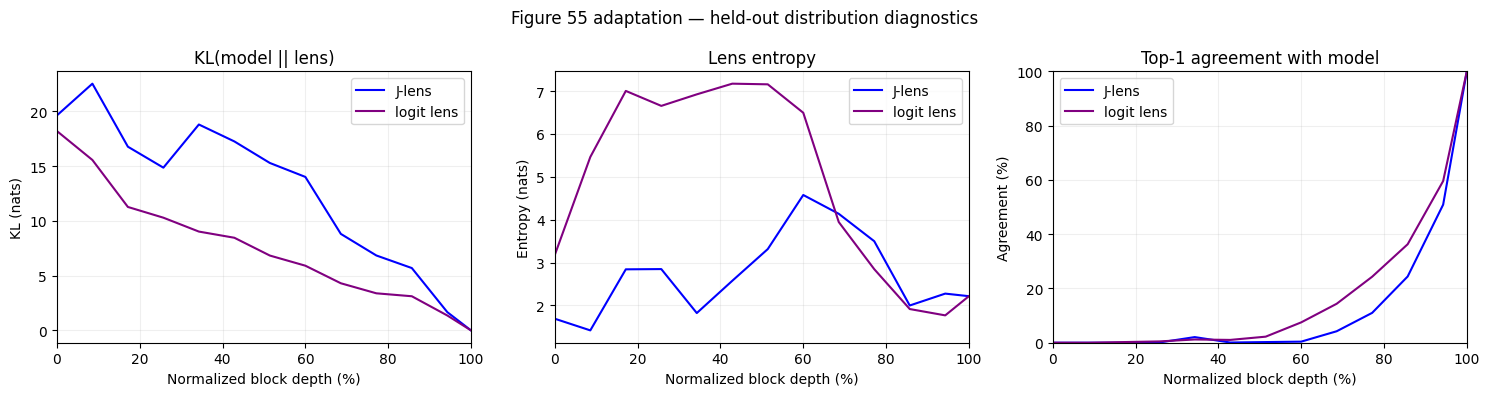

In [33]:
plot_distribution_summary(distributions.layers, n_layers=model.n_layers)
plt.show()

lens vector geometry:   0%|          | 0/13 [00:00<?, ?it/s]

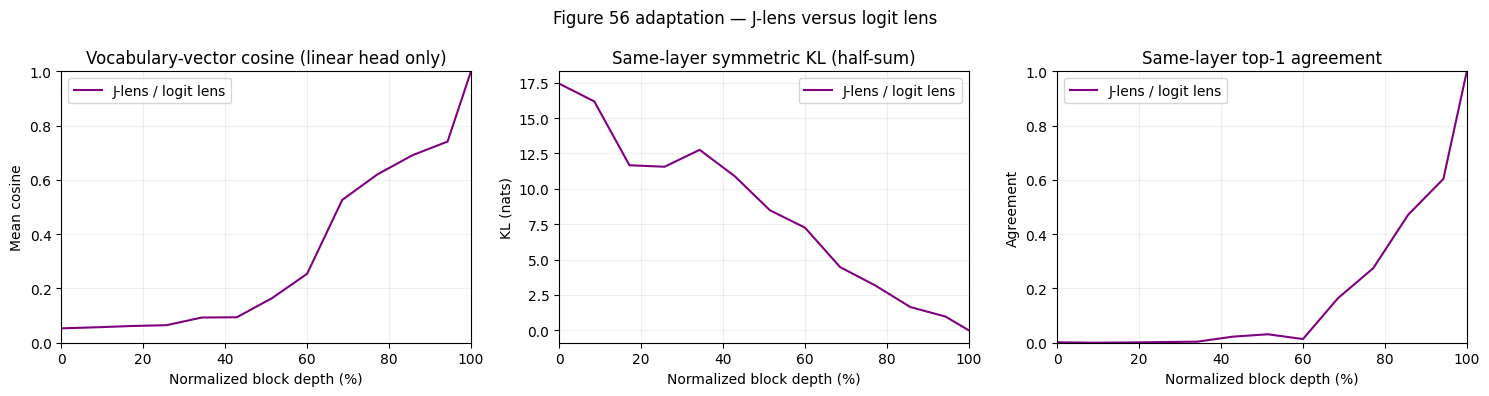

,layer,is_final,status,reason,mean_cosine,n_vocab,n_valid_vectors,n_zero_vectors,weighting,convention
0,0,False,ok,,0.0530,151936,151936,0,vocabulary,linear_head_only: W_U vs W_U @ J
1,3,False,ok,,0.0568,151936,151936,0,vocabulary,linear_head_only: W_U vs W_U @ J
2,6,False,ok,,0.0616,151936,151936,0,vocabulary,linear_head_only: W_U vs W_U @ J
3,9,False,ok,,0.0646,151936,151936,0,vocabulary,linear_head_only: W_U vs W_U @ J
4,12,False,ok,,0.0928,151936,151936,0,vocabulary,linear_head_only: W_U vs W_U @ J
5,15,False,ok,,0.0938,151936,151936,0,vocabulary,linear_head_only: W_U vs W_U @ J
6,18,False,ok,,0.1641,151936,151936,0,vocabulary,linear_head_only: W_U vs W_U @ J
7,21,False,ok,,0.2540,151936,151936,0,vocabulary,linear_head_only: W_U vs W_U @ J
8,24,False,ok,,0.5261,151936,151936,0,vocabulary,linear_head_only: W_U vs W_U @ J
9,27,False,ok,,0.6201,151936,151936,0,vocabulary,linear_head_only: W_U vs W_U @ J


In [34]:
geometry = lens_vector_geometry(model, lens, layers=list(range(0, model.n_layers, LAYER_STRIDE)))
plot_lens_comparison(distributions.pairs, geometry, n_layers=model.n_layers)
plt.show()
display(geometry.round(4))

## 6. Conclusions

All numbers are on the 131 questions Qwen3-4B answers correctly (§2c): 32 multihop, 70
multilingual, 29 order-ops.

* **What counts as "answering correctly" matters more than expected.** Checked on the
  generated continuation, the model gets 131 of 255 targeted questions right. The earlier
  next-token check found 41 and put order-ops at 0%, because Qwen emits a space before the
  digits — a tokenization artifact, not a reasoning failure. Restricting to correct
  questions raises both lenses (§4h): at k=10 the J-lens goes 0.408 -> 0.484 and the logit
  lens 0.390 -> 0.466; at k=1 the logit lens gains more (0.145 -> 0.194 vs 0.140 -> 0.155).
* **Over all layers the two lenses are close, with J behind at the top rank.** Strict
  pass@1 0.119 vs 0.197, pass@10 0.453 vs 0.466 (§4b). Per set (fuzzy, §4g): on multihop J
  leads at k=5 and k=10 (0.516 vs 0.484, 0.710 vs 0.613) but is far behind at k=1 (0.129
  vs 0.323); on multilingual the logit lens leads at every k; on order-ops J leads at k=1
  (0.121 vs 0.017), but that is 29 items, and at k=10 the controls already score 0.13-0.18.
  The Figure 52 sweep (§4f) agrees: AUC ties on multihop (0.589 vs 0.586) and order-ops
  (0.334 vs 0.332), logit ahead on multilingual (0.403 vs 0.483).
* **In the workspace band the logit lens wins outright.** Restricted to layers 12-27, the
  band the paper reads, J trails at every k and on every set (§4c): 0.019 vs 0.094 at k=1,
  0.146 vs 0.274 at k=10, and 0.000 at k=1 on multihop and up to k=10 on order-ops. Both
  lenses' rank-1 hits start around layer 26 (§4e), J's slightly later, where `J_l` is already
  close to the identity (cos(W_U, W_U J_l) = 0.53 at layer 24, 0.74 at 33, §5). That is the
  plain Jacobian lens's known early-layer weakness, and the stated motivation for the later
  J++ variant, which is deliberately not used here.
* **It is not a tokenization artifact.** Fuzzy matching moves J - logit at k=1 from -0.078
  to -0.039 and turns k=5-10 into a narrow J lead (§4g), but does not change the band
  result. Masking the readout to word-like tokens (§4d) leaves the logit lens ahead on
  multilingual (0.357 vs 0.429 at k=10) and ties multihop (0.312 each).
* **The lens nevertheless reads internal content on individual questions.** At layer 24 of
  the §3a probe the J-lens top-1 is the bridge entity ` Italy`, in neither prompt nor
  answer, while the logit lens reads function words; the §3d pages show the same view for
  one correct question per set, and §7 lets you try your own prompts. A lens can carry
  causally effective directions without winning a full-vocabulary rank contest:
  `concept_swap.ipynb` gets 50-51% swap success on correctly answered trials, with
  logit-lens directions at 0.000 in the early bands.
* **Caveats.** One model, one lens, one fit corpus (479 WikiText prompts by this lens's own
  convergence record). Only the three sets with a `target` can be filtered; `poetry`,
  `association` and `typo` are excluded. 29-70 questions per set, so per-set numbers are
  indicative, not tight. Correctness is a string match on 8 greedy tokens; a right answer
  phrased differently (`the Atlantic`) counts as wrong. Ranks are tokenizer-dependent and
  not comparable to the repo's GPT-2 runs. bf16 throughout, matching the dtype the lens was
  fitted in.

## 7. Play with the lens yourself

Everything above is aggregated. This section is for convincing yourself directly: put in a
prompt, name some words to track, and look at what each layer reads out against what the
model actually says next.

**Edit `PLAY_PROMPT` / `PLAY_TRACK` in the next cell and re-run it.** Things worth trying:

* A two-hop fact (`"The currency of the country shaped like a boot is"`) — the bridge
  entity should surface mid-network in the J-lens and not in the logit lens.
* A one-hop fact (`"The capital of France is"`) — no bridge entity, so the two lenses
  should look much more alike.
* Arithmetic (`"(2 + 3) * 4 ="`) — watch whether the intermediate `5` ever appears.
* A prompt in another language, where Qwen's CJK tokens make `mask_display` earn its keep.
* Nonsense (`"Fact: the glorp of the frobnicate is"`) — a lens that "works" should *not*
  produce a confident concept here.

In [35]:
PLAY_PROMPT = "Fact: The currency used in the country shaped like a boot is"
PLAY_TRACK = ["Italy", "euro", "Rome", "France"]
PLAY_POSITION = -1   # which token position to read out; -1 is the last prompt token
PLAY_TOP_N = 8

[transformers] The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


prompt   : 'Fact: The currency used in the country shaped like a boot is'
tokens   : ['Fact', ':', ' The', ' currency', ' used', ' in', ' the', ' country', ' shaped', ' like', ' a', ' boot', ' is']
readout  : position -1 = ' is'


model says: ' the euro.\nWhat is the answer? The country shaped like'



,J-lens,logit lens
layer,,
0,' –' ' …\n\n' ' ….' '….\n\n' '”.\n\n' '’.\n\n'...,'/is' 'lington' '館' 'rael' '紋' '该县' 'いか' '矜'
3,'…”' '”\n' '.”\n' '…”\n\n' '”，' '”.\n\n' '”。\n...,'ocratic' '/is' 'ucht' 'omers' 'rael' '-roll' ...
6,'`.\n\n' '”。\n\n' '`\n\n' '`.\n' '。\n\n' '”.\n...,'もっと' '[number' 'oven' '間違い' '끔' 'ance' 'yı' '珀'
9,' \\`' '`.\n\n' '`.\n' '`;\n\n' '帼' ' &#' 'rae...,' 물론' '끔' ' Федер' '全过程' '-but' '[number' ' an...
12,' \\`' '`.\n' '`.\n\n' ' Britain' ' […' '。\n' ...,'-shaped' ' shaped' '瘾' '[number' '_lib' 'ólic...
15,'吗' '。\\' '？\n' '哪个' ' \\`' '？\n\n' '又称' '://${','蓉' '-shaped' '地区的' '꼴' ' victories' '全国人民' '最...
18,'？\n' '？\n\n' ')?\n' '？”' ')?\n\n' '?”\n\n' '?...,' countries' '全国人民' ' located' ' namely' 'eder...
21,')?\n\n' ')?\n' '?</' '.*/\n' '?”\n\n' ';*/\n'...,' victories' ' where' '其中之一' '其中一个' ' one' ' c...
24,' Italy' '意大利' '欧元' '英镑' 'Italy' ' Italian' '金...,' called' ' currently' ' named' ' typically' '...


,J 'Italy',logit 'Italy',J 'euro',logit 'euro',J 'Rome',logit 'Rome',J 'France',logit 'France'
layer,,,,,,,,
0,3405,78024,13488,62205,44797,35091,1237,15500
3,30728,83855,102996,85947,118774,12880,6641,23922
6,57531,40696,28141,59687,97828,38494,801,25066
9,67113,41257,23332,972,81791,111769,599,38419
12,148,1006,3462,5635,49537,77299,47,2149
15,2086,4776,34595,12810,35992,78063,20,1720
18,248,7432,14877,5127,56707,54245,94,1741
21,155,969,2812,2890,17346,14715,83,2453
24,1,23,74,63,175,5880,103,4137


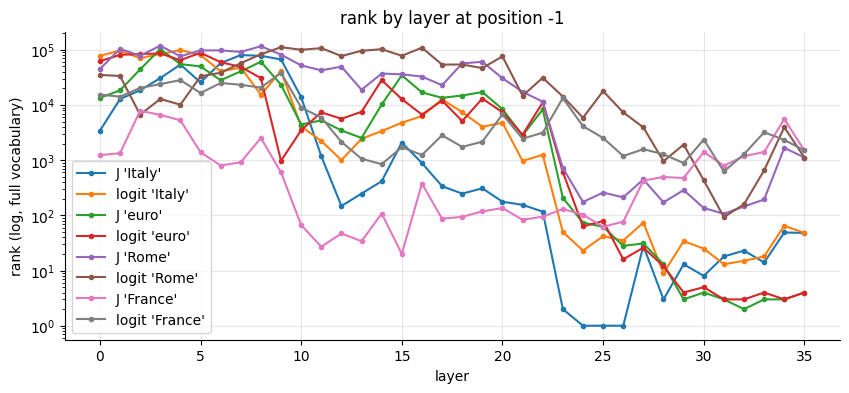

In [36]:
@torch.no_grad()
def explore(prompt, track=(), position=-1, top_n=8, layer_stride=None, continue_for=12):
    # Per-layer readout of both lenses at one position, the ranks of tracked words,
    # and what the model actually generates -- the three things needed to judge a lens.
    stride = layer_stride or LAYER_STRIDE
    layers = sorted({*range(0, model.n_layers, stride), model.n_layers - 1})
    jl_logits, ll_logits = jacobian_lens(model, lens, prompt), logit_lens(model, prompt)
    ids = model.encode(prompt)

    print(f"prompt   : {prompt!r}")
    print(f"tokens   : {[tokenizer.decode([i]) for i in ids[0].tolist()]}")
    print(f"readout  : position {position} = {tokenizer.decode([ids[0, position]])!r}")
    if continue_for:
        generated = hf_model.generate(ids, max_new_tokens=continue_for, do_sample=False,
                                      pad_token_id=tokenizer.pad_token_id)
        print(f"model says: {tokenizer.decode(generated[0, ids.shape[1]:], skip_special_tokens=True)!r}")

    rows = []
    for layer in layers:
        entry = {"layer": layer}
        for name, logits in (("J-lens", jl_logits), ("logit lens", ll_logits)):
            top = logits[layer, position].topk(top_n).indices.tolist()
            entry[name] = " ".join(repr(tokenizer.decode([i])) for i in top)
        rows.append(entry)
    print()
    display(pd.DataFrame(rows).set_index("layer"))

    if track:
        ranks = {}
        for word in track:
            ids_of_word = sorted(fuzzy_spelling_ids(tokenizer, word))
            if not ids_of_word:
                print(f"(skipping {word!r}: unscorable under fuzzy matching)")
                continue
            index = torch.tensor(ids_of_word, device=jl_logits.device)
            for name, logits in (("J", jl_logits), ("logit", ll_logits)):
                scores = logits[:, position]
                best = scores[:, index].max(-1).values
                ranks[f"{name} {word!r}"] = ((scores > best.unsqueeze(-1)).sum(-1) + 1).cpu().numpy()
        frame = pd.DataFrame(ranks, index=range(model.n_layers))
        frame.index.name = "layer"
        display(frame.loc[layers])
        axis = frame.plot(figsize=(10, 4), logy=True, marker=".")
        axis.set_ylabel("rank (log, full vocabulary)")
        axis.set_title(f"rank by layer at position {position}")
        axis.grid(alpha=0.3)
        axis.spines[["top", "right"]].set_visible(False)
        plt.show()


explore(PLAY_PROMPT, track=PLAY_TRACK, position=PLAY_POSITION, top_n=PLAY_TOP_N)

### And the same prompt as an interactive slice

Click any cell to pin that token and see its rank at every position and layer.

In [37]:
slice_page(PLAY_PROMPT, title="Playground", description=PLAY_PROMPT,
           track=tuple(PLAY_TRACK))

0.42 MB page, 88 tracked tokens


### A control: the lens should *not* be confident about nonsense

If a readout looks equally decisive on a prompt with no answer, it is reading the prompt's
surface form rather than a computation.

prompt   : 'Fact: The glorp of the frobnicated widget is'
tokens   : ['Fact', ':', ' The', ' gl', 'orp', ' of', ' the', ' fro', 'bn', 'icated', ' widget', ' is']
readout  : position -1 = ' is'
model says: " a measure of the widget's ability to"



,J-lens,logit lens
layer,,
0,' –' ' …\n\n' ' ….' '”.\n\n' ' .\n\n' '….\n\n'...,'/is' 'lington' 'いか' '館' 'abella' '该县' '紋' 'ot...
3,'”\n' '’.\n\n' '`.\n' '‘' '.”\n' '”.\n\n' '”\n...,'omers' 'antar' '-Sah' 'abella' '-roll' '행' '证...
6,'”。\n\n' '”，' '。\n\n' '，' '`.\n\n' '”的' '”.\n\...,'-vous' 'rael' 'ZW' 'rather' '个多' '另一种' 'omers...
9,' pakistan' ' muslim' ' .\n\n' ' ，' ' malaysia...,'功劳' '另一种' ' instrumental' ' celebrated' 'omer...
12,' \\`' ' �' ' \\<' ' \\<^' '甚么' '\\<^' ' \\%' ...,"'omers' '个多' '""label' ' 물론' '廳' 'acies' ' fool..."
15,' \\`' '甚么' '所谓' ' {@' ';$' ' /*#__' '哲学' ' as...,"'pus' '一个新的' 'Ŷ' '躁' 'abilities' 'acies' ""'lab..."
18,' metaphor' ' metaph' ' metast' ' philosoph' '...,'omers' '的确' '岚' '陣' ' indeed' 'ón' 'óc' '_hat'
21,'哲学' ' philosophical' '量化' ' philosoph' ' meta...,'omers' '岚' ' always' '鹩' '不完' 'ieri' ' often'...
24,' inherently' ' always' ' seldom' ' necessary'...,' always' ' often' ' typically' 'omers' ' desc...


,J 'Italy',logit 'Italy',J 'euro',logit 'euro'
layer,,,,
0,3703,67703,8966,78163
3,31855,82611,96047,97976
6,80373,124386,54877,64231
9,90198,114111,63041,62080
12,74515,34882,96597,85538
15,123239,63164,93174,17660
18,136613,41200,66202,20583
21,113759,96571,61473,77598
24,64021,89390,66776,93471


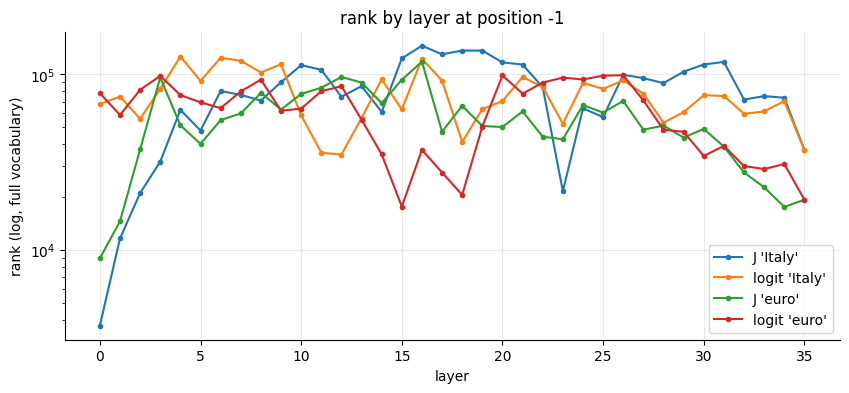

In [38]:
explore("Fact: The glorp of the frobnicated widget is",
        track=["Italy", "euro"], continue_for=8)